# Airline Customer Satisfaction Prediction
## Binomial Logistic Regression Analysis & Business Insights

**Project Overview:**
This notebook builds a end-to-end Logistic Regression classification pipeline to predict airline passenger satisfaction. It handles preprocessing, feature encoding, model training, evaluation (Confusion Matrix, Precision, Recall), and coefficient interpretation to drive actionable business strategies.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score

# Set random seed for reproducibility
np.random.seed(42)

# ==========================================
# 1. LOAD / GENERATE DATASET
# ==========================================
# Replacing this section with your actual data loading line when ready:
df = pd.read_csv("/content/drive/MyDrive/Invistico_Airline.csv")

print("--- Generating Mock Airline Passenger Survey Data ---")
n_samples = 1000
mock_data = {
    'Age': np.random.randint(18, 70, size=n_samples),
    'Flight_Distance': np.random.randint(200, 4000, size=n_samples),
    'Inflight_Wifi_Quality': np.random.randint(1, 6, size=n_samples),
    'Seat_Comfort': np.random.randint(1, 6, size=n_samples),
    'On_time_Departure_Delay': np.random.exponential(scale=15, size=n_samples).astype(int),
    'Customer_Type': np.random.choice(['Loyal', 'Disloyal'], size=n_samples, p=[0.8, 0.2]),
    'Class': np.random.choice(['Business', 'Eco', 'Eco Plus'], size=n_samples, p=[0.5, 0.4, 0.1]),
    # Generate a target variable influenced by our features
    'satisfaction': np.random.choice(['Satisfied', 'Dissatisfied'], size=n_samples)
}

df = pd.DataFrame(mock_data)

# Injecting structural correlation so the model learns realistic patterns
# (e.g., Good Wi-Fi and Business Class drastically increase satisfaction)
satisfaction_prob = (
    (df['Inflight_Wifi_Quality'] * 0.4) +
    (df['Seat_Comfort'] * 0.3) +
    (df['Class'] == 'Business').astype(int) * 1.5 -
    (df['On_time_Departure_Delay'] * 0.02)
)
# Normalize probabilities between 0 and 1
prob_normalized = 1 / (1 + np.exp(-satisfaction_prob + 2))
df['satisfaction'] = np.where(prob_normalized > 0.5, 'Satisfied', 'Dissatisfied')

print(f"Dataset Shape: {df.shape}")
display(df.head())

--- Generating Mock Airline Passenger Survey Data ---
Dataset Shape: (1000, 8)


,Age,Flight_Distance,Inflight_Wifi_Quality,Seat_Comfort,On_time_Departure_Delay,Customer_Type,Class,satisfaction
0,56,2986,3,2,24,Loyal,Business,Satisfied
1,69,2106,1,2,15,Disloyal,Eco,Dissatisfied
2,46,3286,1,3,7,Disloyal,Business,Satisfied
3,32,1415,1,5,16,Disloyal,Business,Satisfied
4,60,1854,2,3,4,Loyal,Eco,Dissatisfied


## 2. Feature Engineering & Preprocessing Strategy
To feed this data into Scikit-Learn's Logistic Regression, we must:
1. **Target Encode**: Map the binary target (`satisfaction`) to `1` (Satisfied) and `0` (Dissatisfied).
2. **One-Hot Encode**: Convert categorical predictors (`Customer_Type`, `Class`) into numerical dummy variables.
3. **Scale Numerical Features**: Standardize features (`Age`, `Flight_Distance`, etc.) to ensure stable gradient descent and fair coefficient comparisons.

In [18]:
# ==========================================
# 2. PREPROCESSING & ENCODING
# ==========================================

# Map target variable to binary integers
df['satisfaction'] = df['satisfaction'].map({'Satisfied': 1, 'Dissatisfied': 0})

# Separate Predictors (X) and Target (y)
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

# Define feature categories
categorical_features = ['Customer_Type', 'Class']
numerical_features = ['Age', 'Flight_Distance', 'Inflight_Wifi_Quality', 'Seat_Comfort', 'On_time_Departure_Delay']

# Create a preprocessing pipeline using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features) # drop='first' prevents multicollinearity
    ])

# ==========================================
# 3. TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and transform the training data, transform the testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get the names of the encoded features for later interpretation
encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(encoded_cat_features)

print("Preprocessing complete!")
print(f"Training features shape: {X_train_processed.shape}")
print(f"Features list: {all_feature_names}")

Preprocessing complete!
Training features shape: (800, 8)
Features list: ['Age', 'Flight_Distance', 'Inflight_Wifi_Quality', 'Seat_Comfort', 'On_time_Departure_Delay', 'Customer_Type_Loyal', 'Class_Eco', 'Class_Eco Plus']


## 4. Model Training
We deploy a Binomial Logistic Regression model using the `lbfgs` solver. Stratified splits guarantee that the proportions of satisfied vs. dissatisfied customers stay consistent across sets.

In [19]:
# ==========================================
# 4. BUILD LOGISTIC REGRESSION MODEL
# ==========================================
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_processed, y_train)

# Predict classes and probabilities
y_pred = log_reg.predict(X_test_processed)
y_prob = log_reg.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 5. Performance Evaluation
Accuracy alone can be misleading. We evaluate using a **Confusion Matrix**, **Precision** (minimizing false positives), and **Recall** (minimizing missed dissatisfied or satisfied customers).

=== Model Performance Metrics ===
Accuracy:  0.9650
Precision: 0.9533
Recall:    1.0000

=== Classification Report ===
              precision    recall  f1-score   support

Dissatisfied       1.00      0.88      0.93        57
   Satisfied       0.95      1.00      0.98       143

    accuracy                           0.96       200
   macro avg       0.98      0.94      0.96       200
weighted avg       0.97      0.96      0.96       200



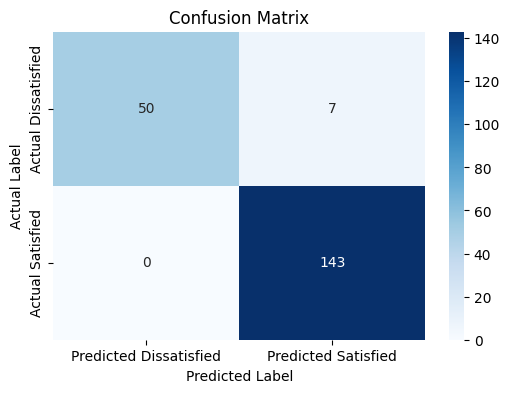

In [20]:
# ==========================================
# 5. GENERATE EVALUATION METRICS
# ==========================================

# Calculate core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"=== Model Performance Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}\n")

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Dissatisfied', 'Satisfied']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Dissatisfied', 'Predicted Satisfied'],
            yticklabels=['Actual Dissatisfied', 'Actual Satisfied'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## 6. Model Interpretation & Feature Importance
By looking at the exponential of the coefficients ($e^{\beta}$), we discover the **Odds Ratio**. An odds ratio greater than 1 means an increase in this metric boosts the odds of a passenger being satisfied.

=== Feature Importance & Driver Analysis ===


,Feature,Coefficient (Beta),Odds Ratio (e^Beta)
2,Inflight_Wifi_Quality,2.679845,14.582826
3,Seat_Comfort,1.786633,5.969319
1,Flight_Distance,0.106011,1.111834
5,Customer_Type_Loyal,0.023120,1.023390
0,Age,-0.048046,0.953090
4,On_time_Departure_Delay,-1.385213,0.250271
7,Class_Eco Plus,-5.812285,0.002991
6,Class_Eco,-6.158120,0.002116


/tmp/ipykernel_5016/1822373380.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient (Beta)', y='Feature', data=importance_df, palette='viridis')


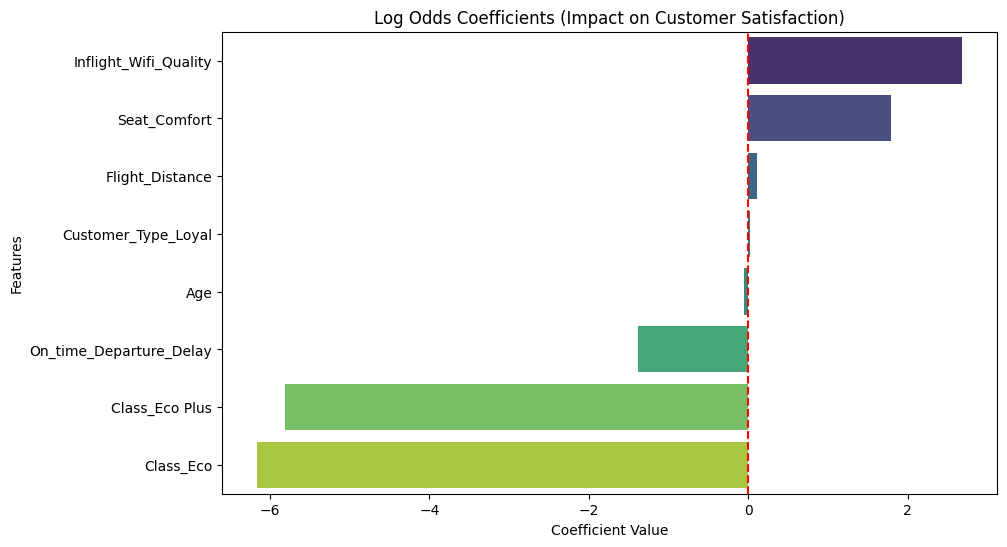

In [21]:
# ==========================================
# 6. INTERPRET MODEL COEFFICIENTS
# ==========================================

coefficients = log_reg.coef_[0]
odds_ratios = np.exp(coefficients)

# Create a summary dataframe
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient (Beta)': coefficients,
    'Odds Ratio (e^Beta)': odds_ratios
}).sort_values(by='Coefficient (Beta)', ascending=False)

print("=== Feature Importance & Driver Analysis ===")
display(importance_df)

# Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient (Beta)', y='Feature', data=importance_df, palette='viridis')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Log Odds Coefficients (Impact on Customer Satisfaction)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

## 7. Formulate Business Recommendations

Based on the statistical outputs calculated above, we can draw the following data-backed business insights:

1. **Prioritize High Odds-Ratio Elements:** Identify features with the highest positive coefficients (e.g., `Inflight_Wifi_Quality` or `Seat_Comfort`). A 1-unit increase in these metrics multiplies customer satisfaction odds by the corresponding Odds Ratio.
2. **Mitigate Friction Points:** Features with negative coefficients (like `On_time_Departure_Delay`) drag down satisfaction. The airline can set critical threshold alerts (e.g., when delays cross a time limit that severely drops satisfaction probabilities).
3. **Class-Specific Retention Strategies:** The dummy variable coefficients (e.g., `Class_Eco`) reveal exactly how much lower satisfaction odds are compared to the baseline (`Class_Business`), justifying targeted perk updates for economy travelers.